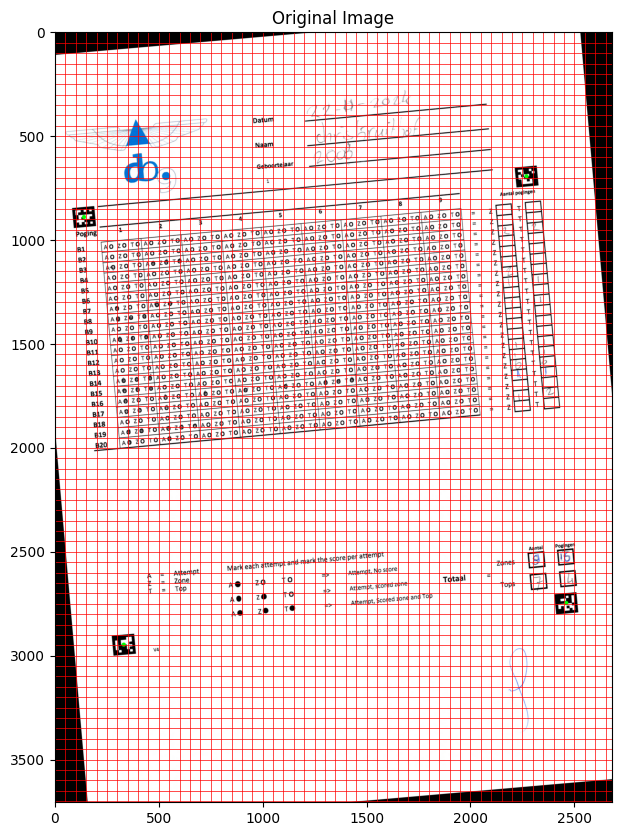

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import sys
import numpy as np
from pathlib import Path

sys.path.append(os.path.join(os.path.dirname(Path.cwd()), "pipeline"))
import aruco_handler

# Load the image
image = plt.imread("aruco_flatten_test_image.png")
image = np.array(image*255, dtype=np.uint8)

# Add artifical tilt to the image to limit test the system"s ability to detect and correct for it
artificial_tilt_angle = 5  # degrees

# First pad the image to prevent cropping during rotation
pad_size = 100  # pixels
image = cv2.copyMakeBorder(image, pad_size, pad_size, pad_size, pad_size, cv2.BORDER_CONSTANT, value=[255, 255, 255])
(h, w) = image.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, artificial_tilt_angle, 1.0)
image = cv2.warpAffine(image, M, (w, h))

# Perform ArUco marker detection
aruco_markers = aruco_handler.detect_aruco_markers(image)

def plot_image(image, aruco_markers=None, show_grid=True):

	if aruco_markers is not None:
		for marker in aruco_markers:
			cv2.circle(image, marker, 10, (0, 255, 0), -1)

	# Display the original image
	plt.figure(figsize=(10, 10))
	plt.imshow(image, vmin=0, vmax=255)
	plt.title("Original Image")

	if show_grid:
		# Plot horizontal lines
		for y in range(0, image.shape[0], 50):
			plt.axhline(y=y, color="red", linestyle="-", linewidth=0.5)

		# Plot vertical lines
		for x in range(0, image.shape[1], 50):
			plt.axvline(x=x, color="red", linestyle="-", linewidth=0.5)


	plt.show()

plot_image(image, aruco_markers, show_grid=True)

Input shape: (3706, 2681, 3)
Output shape: (3706, 2681, 3)


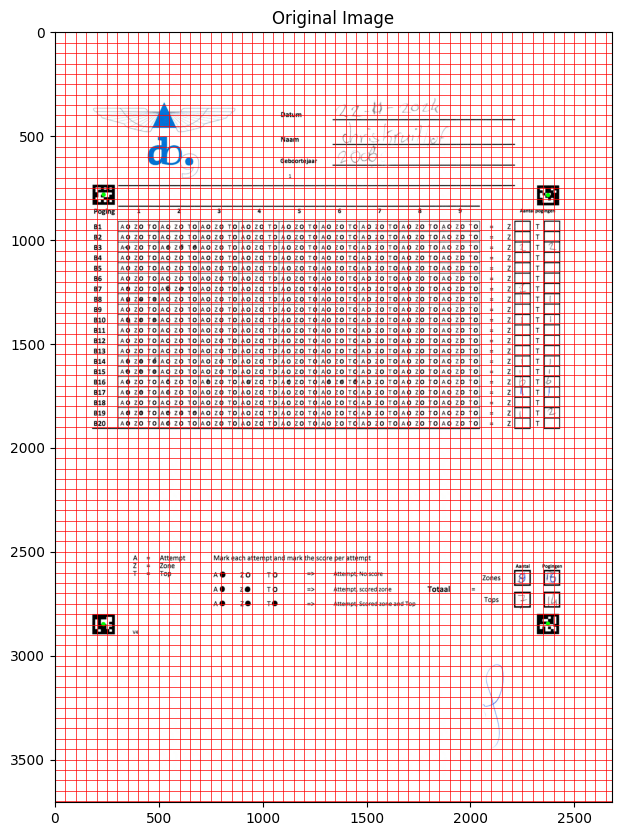

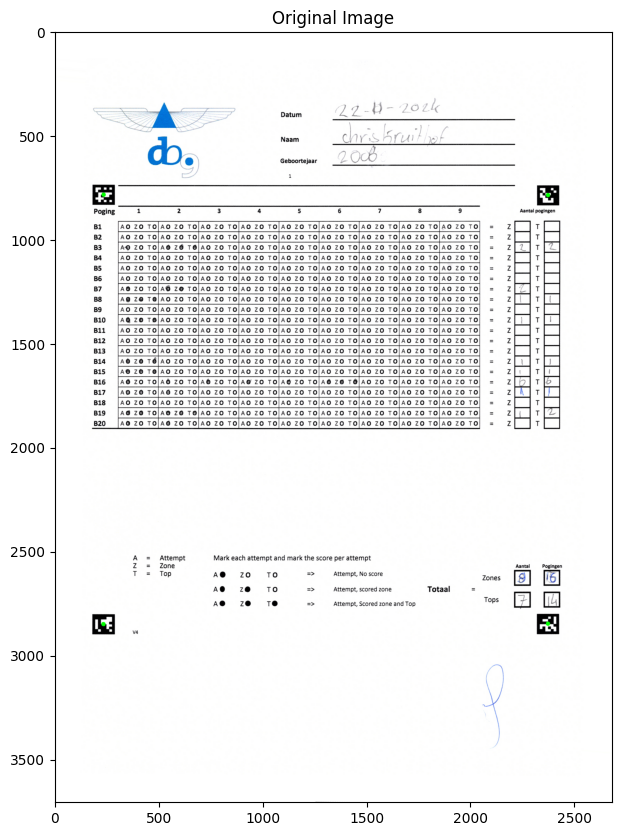

In [17]:
input_shape = image.shape

# Flatten the image using the detected ArUco markers
flattened_image, flattened_aruco_markers = aruco_handler.rotate_image_to_flatten_aruco_markers(image, aruco_markers)

output_shape = flattened_image.shape

print(f"Input shape: {input_shape}")
print(f"Output shape: {output_shape}")

plot_image(flattened_image, aruco_markers=flattened_aruco_markers, show_grid=True)
plot_image(flattened_image, aruco_markers=flattened_aruco_markers, show_grid=False)